In [1]:
import numpy as np
import networkx as nx

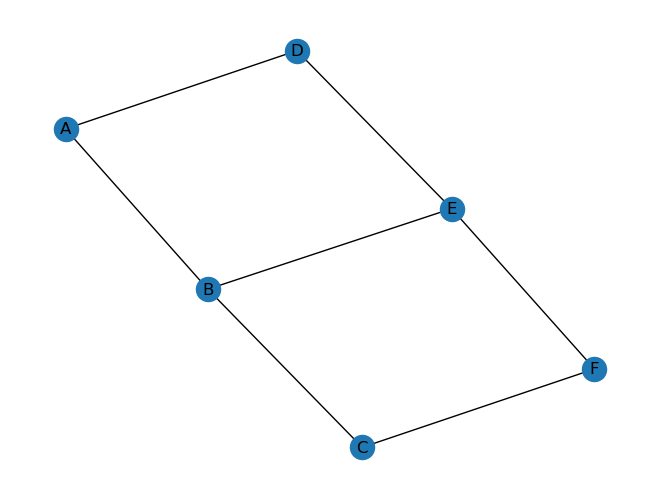

In [6]:
G = nx . Graph ([('A','B'),('B','C'),('C','F'),('A','D'),('D','E'),('E','F'),('B','E')])
nx . draw (G , with_labels = True )

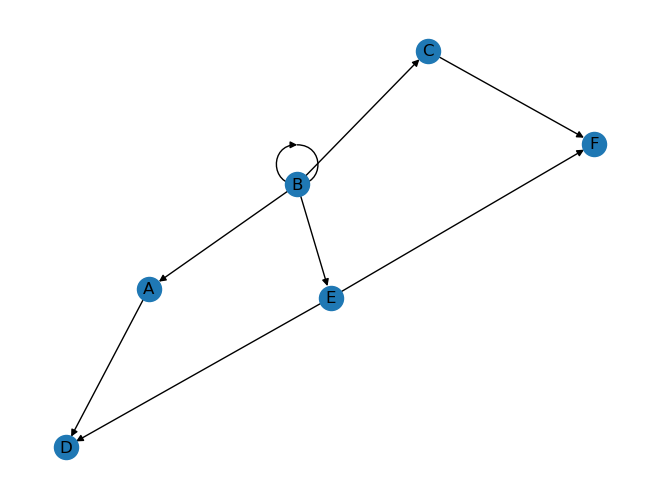

In [4]:
Go = nx . DiGraph ([('B','B'),('B','C'),('B','A'),('B','E'),('A','D'),('E','D'),('E','F'),('C','F')])
nx . draw (Go , with_labels = True )

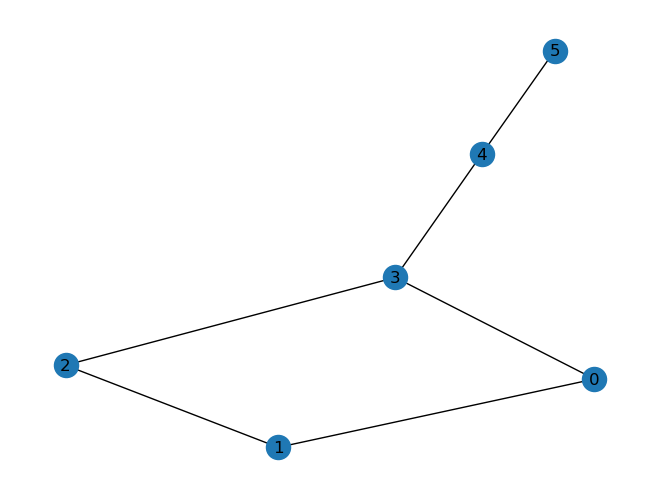

In [7]:
M = np . array ([[0,1,0,1,0,0],
                 [1,0,1,0,0,0],
                 [0,1,0,1,0,0],
                 [1,0,1,0,1,0],
                 [0,0,0,1,0,1],
                 [0,0,0,0,1,0]])
Gc = nx . Graph ( M )
nx . draw ( Gc , with_labels = True )

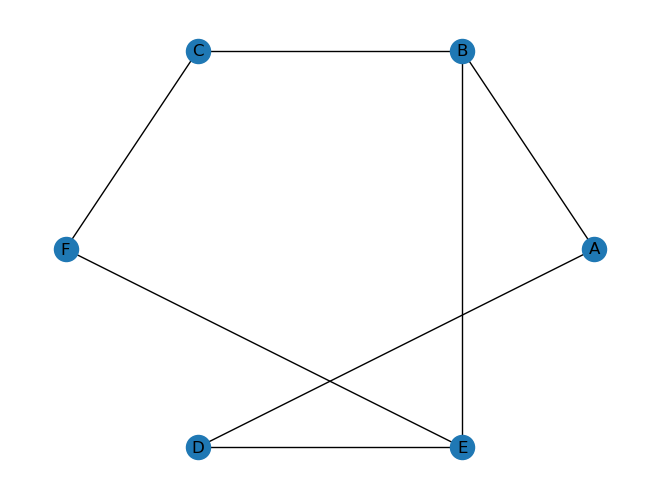

In [10]:
position = nx.circular_layout(G)
nx.draw(G,with_labels=True,pos=position)



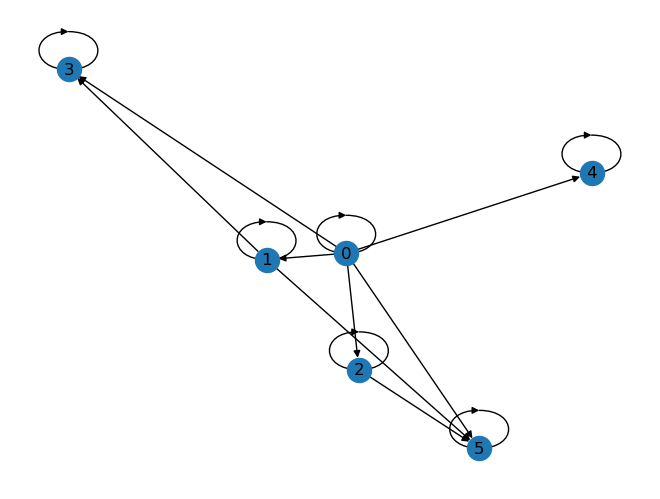

In [19]:
def div_graph(n):
    M = np . zeros ([n,n])
    for i in range(1,n+1):
        for j in range(i,n+1,i):
            M[i-1,j-1] = 1
    G = nx . DiGraph ( M )
    return G

G = div_graph(6)
nx . draw ( G , with_labels = True )

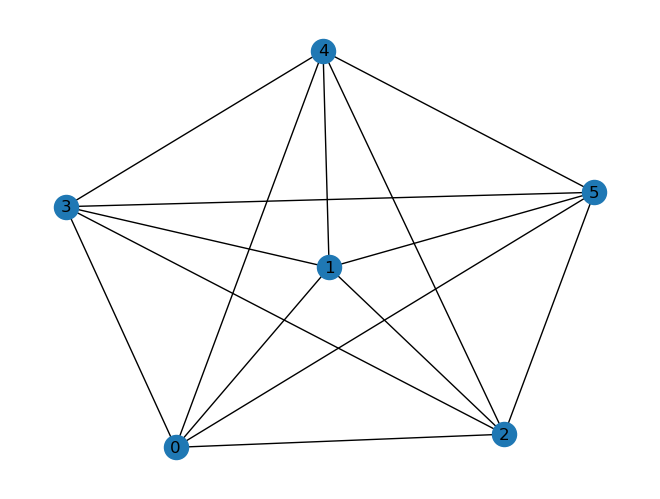

In [21]:
def complete_graph(n):
    M = np . ones ([n,n]) - np . eye (n)
    G = nx . Graph ( M )
    return G
G = complete_graph(6)
nx . draw ( G , with_labels = True )

In [ ]:
def test_mat(M):
    
    # Vérifier que M est un array numpy 2D
    if not isinstance(M, np.ndarray) or M.ndim != 2:
        return "Non graphe"
    
    # Vérifier que la matrice est carrée
    n, m = M.shape
    if n != m:
        return "Non graphe"
    
    # Vérifier que tous les éléments sont des entiers 0 ou 1
    if not np.all(np.isin(M, [0, 1])):
        return "Non graphe"
    
    # Vérifier si la matrice est symétrique (graphe non orienté)
    # et que la diagonale contient seulement des 0 (graphe simple)
    if np.array_equal(M, M.T) and np.all(np.diag(M) == 0):
        return "Graphe non orienté"
    else:
        return "Graphe orienté"
    


In [ ]:
def renommer_sommets(D):
    sommets_originaux = sorted(D.keys())
    mapping = {ancien: nouveau for nouveau, ancien in enumerate(sommets_originaux)}
    nouveau_D = {}
    
    for ancien_sommet, voisins in D.items():
        nouveau_sommet = mapping[ancien_sommet]
        nouveaux_voisins = [mapping[v] for v in voisins]
        nouveau_D[nouveau_sommet] = nouveaux_voisins
    
    return nouveau_D